<a href="https://colab.research.google.com/github/themehmi/Colab-Files/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction**


**In simple terms, k-Nearest Neighbors (k-NN) is a machine learning algorithm that makes predictions based on the idea that "similar things exist in close proximity."**

**Think of it like moving to a new neighborhood: if you want to know if the area is quiet or noisy, you look at the 3 or 5 houses closest to you. If most of them are quiet, you assume your house will be too.**

# **How it Works**

How It Works (The 3-Step Process):

**Store the Data**: Unlike other algorithms, k-NN doesn't "learn" a complex formula. It simply remembers all the training data points.

* **Calculate Distance**: When you give it a new, unknown data point, it calculates the distance between that point and every other point in its memory.

* **Vote (The "k" Factor)**: It looks at the k closest points (the "neighbors").

* **For Classification**: The new point is assigned to the class that is most common among its neighbors.

* **For Regression**: The new point is assigned the average value of its neighbors.

Why the "k" MattersThe value of $k$ is the most important setting you'll choose:
* Small $k$ (e.g., $k=1$): The model is very sensitive to noise or outliers. It might "overfit," meaning it follows the training data too closely.
* Large $k$ (e.g., $k=20$): The model becomes more stable but might "underfit," missing smaller patterns in the data because it's averaging too many points.

<img src= "https://media.licdn.com/dms/image/v2/D4D12AQEaIeOIleYxQw/article-cover_image-shrink_600_2000/article-cover_image-shrink_600_2000/0/1711781577058?e=2147483647&v=beta&t=F4KOa5-9KrMTNzkxJ9FIRxNFHdvn3nd_Xu00CI4I1Lo">

# **Implementation**

Key Takeaways
* Always apply feature scaling before KNN
* Use cross-validation for reliable evaluation
* Prefer distance weighting over uniform weighting
* Optimize k (number of neighbors) using tuning methods
* Be aware of curse of dimensionality in high-dimensional data


KNN is non-parametric because it does not summarize data into a fixed set of parameters and makes predictions directly from the data without assuming any underlying distribution.

In [ ]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris, load_wine, fetch_california_housing, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, validation_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, mean_squared_error, r2_score, mean_absolute_error
)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.color':       '#E0E0E0',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.labelsize':   12,
})

BLUE  = '#1A56DB'
TEAL  = '#0E9F6E'
AMBER = '#FF8C00'
RED   = '#E53E3E'
NAVY  = '#0D1B4B'

print('All imports successful!')
print(f'NumPy {np.__version__} | Pandas {pd.__version__}')


All imports successful!
NumPy 2.0.2 | Pandas 2.2.2


In [ ]:
#load dataset
df=pd.read_csv("https://raw.githubusercontent.com/themehmi/datasets/refs/heads/main/auto-mpg.csv")
#dropping car name because it got nothing to do with mpg
df=df.drop("car name", axis=1)
df['horsepower'] = df['horsepower'].replace('?', np.nan).astype(float)
df['horsepower'].fillna(df['horsepower'].median(), inplace=True)
df.head()
#

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 25.0 KB


In [ ]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


Train_Test Split

In [ ]:
X=df.drop("mpg", axis=1)
y=df['mpg']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

R2 Score: 0.7660
MAE: 2.77 MPG


Text(0, 0.5, 'Predicted MPG')

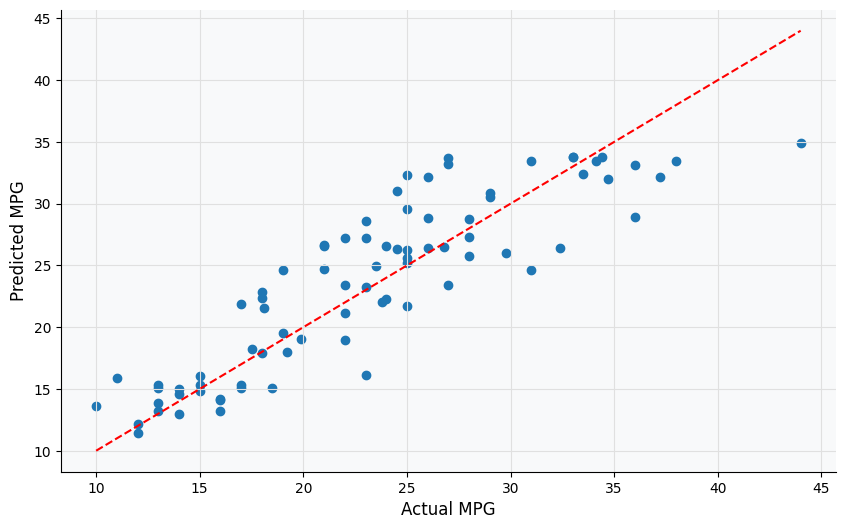

In [ ]:
#evaluating wuthout hypertuning
model1 = KNeighborsRegressor(n_neighbors=5)
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} MPG")

#plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')

# **Hypertuning and Scaling**

In [ ]:
#feature scaling and CV
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the "Grid" of parameters you want to test
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    estimator=KNeighborsRegressor()
    , param_grid=param_grid
    , cv=5
    , scoring='neg_mean_squared_error'
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {-grid_search.best_score_:.2f}") #

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best CV Score: 9.36


In [ ]:
#Evaluation
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test_scaled)

print(f"Final R2 Score: {r2_score(y_test, predictions):.4f}")
print(f"Final MAE: {mean_absolute_error(y_test, predictions):.2f} MPG")

Final R2 Score: 0.9013
Final MAE: 1.76 MPG


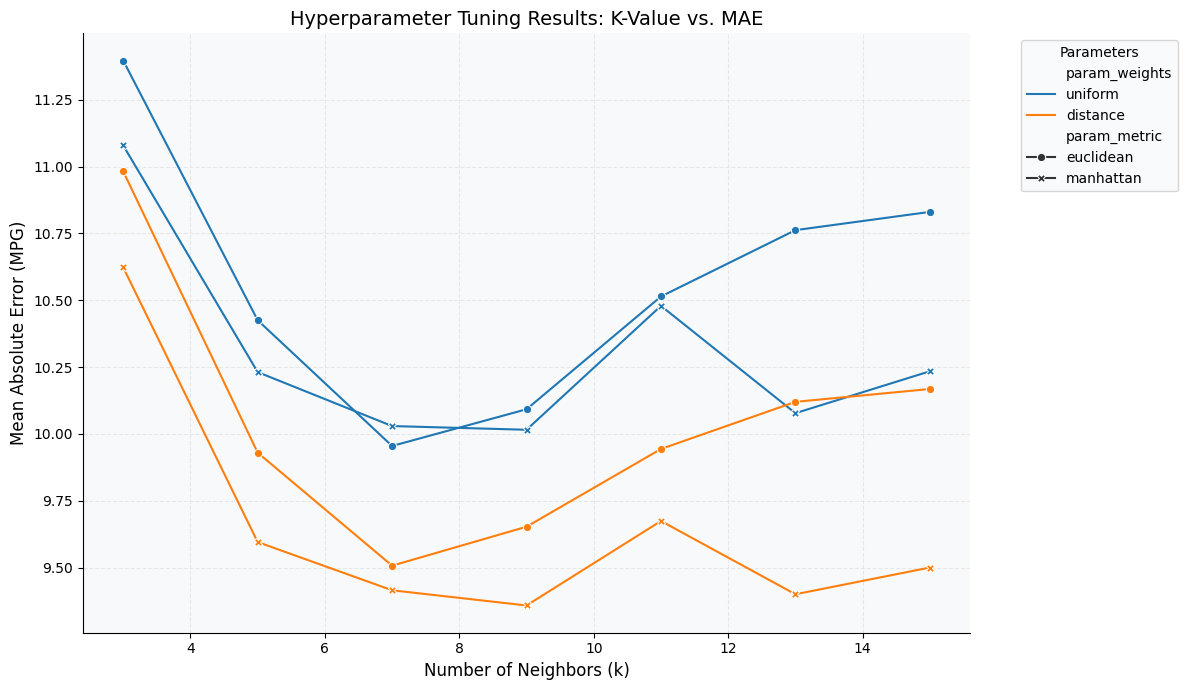

In [ ]:
#plotting
grid_search.fit(X_train_scaled, y_train)

# Convert results to a DataFrame
import pandas as pd
results = pd.DataFrame(grid_search.cv_results_)

# Extract the error (scoring was 'neg_mean_absolute_error', so multiply by -1)
results['mae'] = -results['mean_test_score']

plt.figure(figsize=(12, 7))

# Plotting k vs MAE, distinguished by weights and metrics
sns.lineplot(
    data=results,
    x='param_n_neighbors',
    y='mae',
    hue='param_weights',
    style='param_metric',
    markers=True,
    dashes=False
)

plt.title('Hyperparameter Tuning Results: K-Value vs. MAE', fontsize=14)
plt.xlabel('Number of Neighbors (k)', fontsize=12)
plt.ylabel('Mean Absolute Error (MPG)', fontsize=12)
plt.legend(title='Parameters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Evaluating Using Best Parameters We Found Using GridSearchCV

R2 Score: 0.9013
MAE: 1.76 MPG


Text(0, 0.5, 'Predicted MPG')

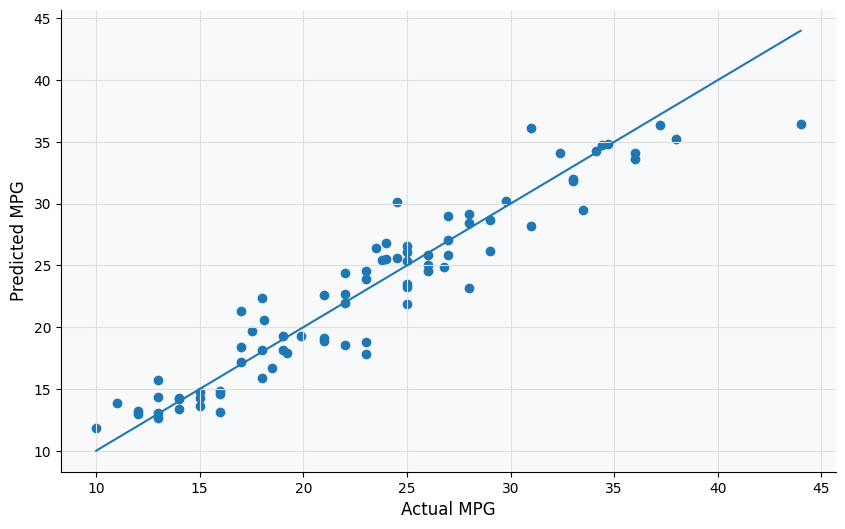

In [ ]:
model2=KNeighborsRegressor(n_neighbors=9, weights='distance', metric='manhattan')
model2.fit(X_train_scaled, y_train)
y_pred = model2.predict(X_test_scaled)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} MPG")
#plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')

In [ ]:
#save model using joblib
import joblib
joblib.dump(model2, 'model2.joblib')

['model2.joblib']

In [ ]:
#loaded saved model
loaded_model = joblib.load('model2.joblib')
#